# Análise Exploratória de Dados - Bank Marketing
## Parte 1 - Análise Descritiva e Visualização

Este notebook apresenta uma análise exploratória do dataset Bank Marketing, que contém dados de campanhas de marketing de um banco português.

### 1. Importação das Bibliotecas e Carregamento dos Dados

In [ ]:
# Instalação do pacote ucimlrepo (importando o dataset)
!pip install ucimlrepo

In [ ]:
# Importação das bibliotecas necessárias
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [ ]:
# Carregamento do dataset Bank Marketing
bank_marketing = fetch_ucirepo(id=222)

# Separando features (X) e target (y)
X = bank_marketing.data.features
y = bank_marketing.data.targets

print('Features (X) columns:')
print(X.columns)

print('\nTargets (y) columns:')
print(y.columns)

Features (X) columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome'],
      dtype='object')

Targets (y) columns:
Index(['y'], dtype='object')


In [ ]:
# Juntando X e y em um único DataFrame para facilitar a análise
df = pd.concat([X, y], axis=1)

# Visualizando as primeiras linhas
print('Primeiras 5 linhas do dataset:')
df.head()

Primeiras 5 linhas do dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
# Informações gerais sobre o dataset
print('Informações do Dataset:')
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')
print('\nTipos de dados:')
print(df.dtypes)

Informações do Dataset:
Número de linhas: 45211
Número de colunas: 17

Tipos de dados:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object


In [ ]:
# Estatísticas descritivas das variáveis numéricas
print('Estatísticas Descritivas:')
df.describe()

Estatísticas Descritivas:


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
# Verificando valores nulos
print('Valores Nulos por Coluna:')
print(df.isnull().sum())

Valores Nulos por Coluna:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [ ]:
# Distribuição da variável target (y)
print('Distribuição da Variável Target (y):')
print(df['y'].value_counts())
print('\nPercentual:')
print(df['y'].value_counts(normalize=True) * 100)

Distribuição da Variável Target (y):
y
no     39922
yes     5289
Name: count, dtype: int64

Percentual:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


---
## Perguntas de Análise Exploratória
---

### Pergunta 1: A idade do cliente influencia na aceitação do depósito a prazo?

**Variável analisada:** `age` (idade)

**Justificativa:** Pessoas mais velhas ou aposentadas tendem a ter mais capital acumulado para investir, enquanto os mais jovens podem ter orçamentos mais apertados.

In [ ]:
# Estatísticas da idade por grupo (sim/não)
print('Estatísticas da Idade por Resultado da Campanha:')
print(df.groupby('y')['age'].describe())

Estatísticas da Idade por Resultado da Campanha:
       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39922.0  40.838986  10.172662  18.0  33.0  39.0  48.0  95.0
yes   5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


/tmp/ipykernel_37092/2399387976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='age', data=df, palette='Set2')


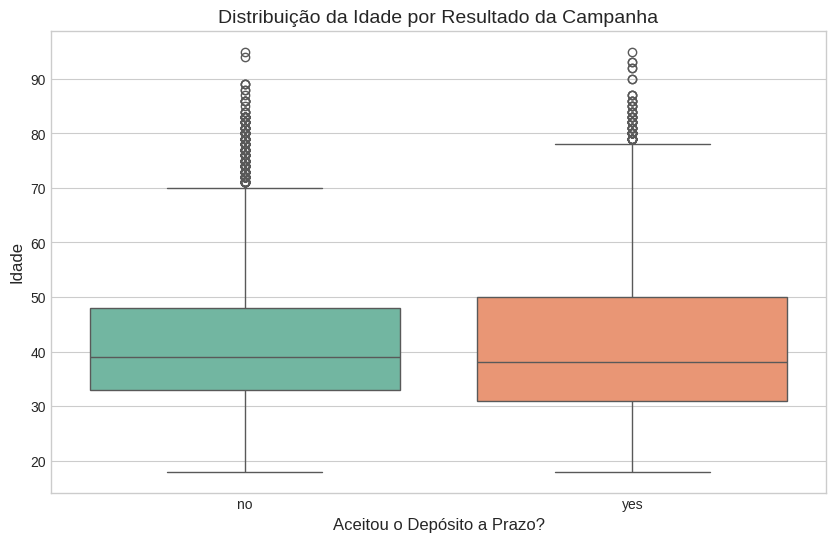

In [ ]:
# Boxplot - Idade vs Resultado
plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='age', data=df, palette='Set2')
plt.title('Distribuição da Idade por Resultado da Campanha', fontsize=14)
plt.xlabel('Aceitou o Depósito a Prazo?', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.show()

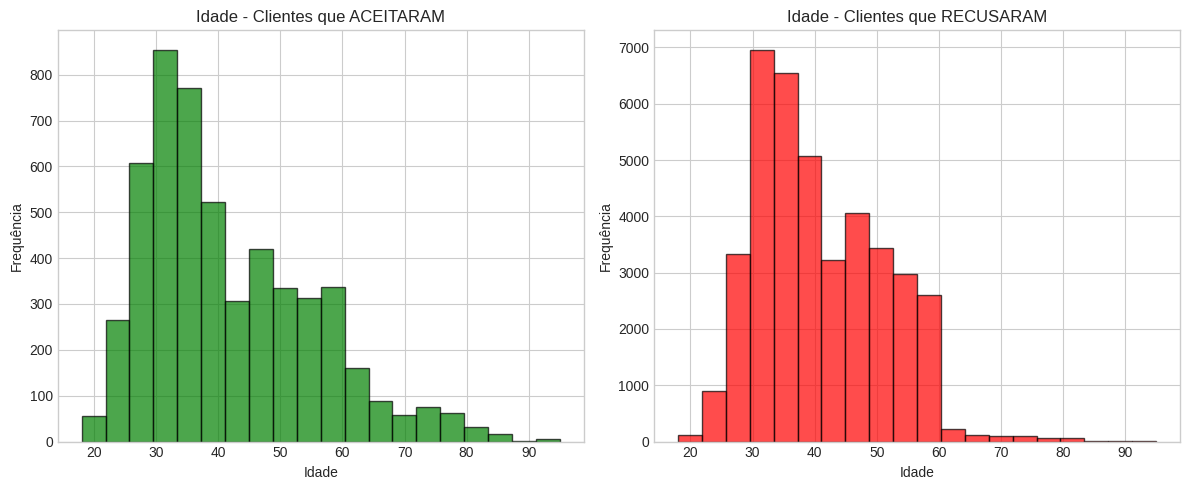

In [ ]:
# Histograma - Distribuição da Idade por Resultado
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['y'] == 'yes']['age'].hist(bins=20, color='green', alpha=0.7, edgecolor='black')
plt.title('Idade - Clientes que ACEITARAM', fontsize=12)
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
df[df['y'] == 'no']['age'].hist(bins=20, color='red', alpha=0.7, edgecolor='black')
plt.title('Idade - Clientes que RECUSARAM', fontsize=12)
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

**Conclusão Pergunta 1:** A análise mostra que a idade média dos clientes que aceitaram é ligeiramente maior. Clientes mais velhos (acima de 60 anos) e mais jovens (abaixo de 30 anos) parecem ter maior propensão a aceitar o depósito a prazo.

---
### Pergunta 2: Clientes com saldo bancário médio anual maior são os que mais aderem ao produto?

**Variável analisada:** `balance` (saldo bancário)

**Justificativa:** É intuitivo pensar que quem tem dinheiro sobrando no banco tem mais chance de aceitar uma oferta de investimento.

In [ ]:
# Estatísticas do saldo por grupo (sim/não)
print('Estatísticas do Saldo Bancário por Resultado da Campanha:')
print(df.groupby('y')['balance'].describe())

Estatísticas do Saldo Bancário por Resultado da Campanha:
       count         mean          std     min    25%    50%     75%       max
y                                                                             
no   39922.0  1303.714969  2974.195473 -8019.0   58.0  417.0  1345.0  102127.0
yes   5289.0  1804.267915  3501.104777 -3058.0  210.0  733.0  2159.0   81204.0


/tmp/ipykernel_37092/1325741297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='balance', data=df, palette='Set2')


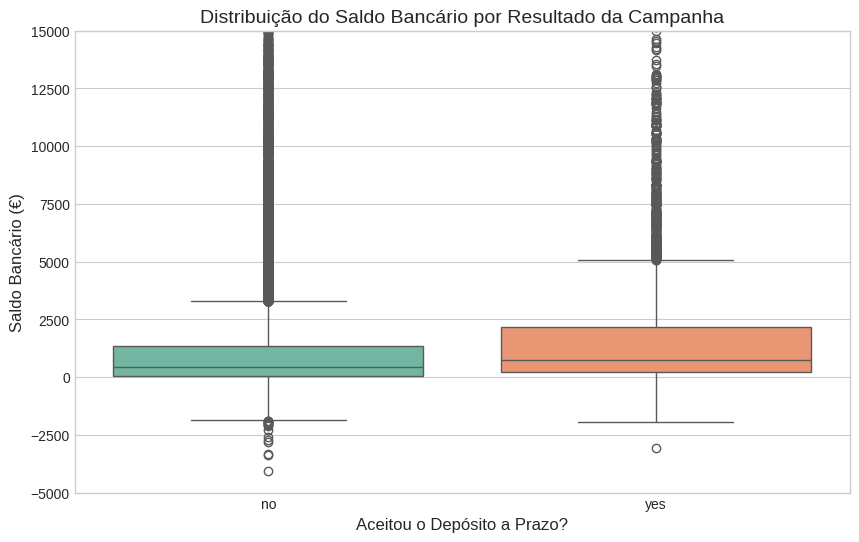

In [ ]:
# Boxplot - Saldo vs Resultado
plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='balance', data=df, palette='Set2')
plt.title('Distribuição do Saldo Bancário por Resultado da Campanha', fontsize=14)
plt.xlabel('Aceitou o Depósito a Prazo?', fontsize=12)
plt.ylabel('Saldo Bancário (€)', fontsize=12)
plt.ylim(-5000, 15000)  # Limitando para melhor visualização
plt.show()

Média do Saldo Bancário:
y
no     1303.714969
yes    1804.267915
Name: balance, dtype: float64


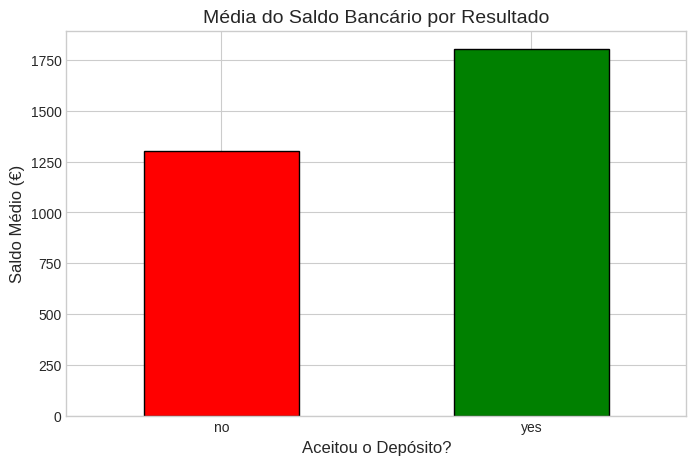

In [ ]:
# Média do saldo por resultado
media_saldo = df.groupby('y')['balance'].mean()
print('Média do Saldo Bancário:')
print(media_saldo)

# Gráfico de barras
plt.figure(figsize=(8, 5))
media_saldo.plot(kind='bar', color=['red', 'green'], edgecolor='black')
plt.title('Média do Saldo Bancário por Resultado', fontsize=14)
plt.xlabel('Aceitou o Depósito?', fontsize=12)
plt.ylabel('Saldo Médio (€)', fontsize=12)
plt.xticks(rotation=0)
plt.show()

**Conclusão Pergunta 2:** Sim, clientes com saldo bancário médio maior tendem a aceitar mais o depósito a prazo. A média do saldo dos que aceitaram é significativamente maior do que dos que recusaram.

---
### Pergunta 3: O fato de ter um empréstimo imobiliário ativo diminui a chance de investir?

**Variável analisada:** `housing` (empréstimo imobiliário)

**Justificativa:** Quem paga parcela de financiamento de casa costuma ter boa parte da renda comprometida.

In [ ]:
# Tabela cruzada - Housing vs Resultado
tabela_housing = pd.crosstab(df['housing'], df['y'], normalize='index') * 100
print('Taxa de Aceitação por Status de Empréstimo Imobiliário (%):')
print(tabela_housing)

Taxa de Aceitação por Status de Empréstimo Imobiliário (%):
y               no        yes
housing                      
no       83.297645  16.702355
yes      92.300040   7.699960


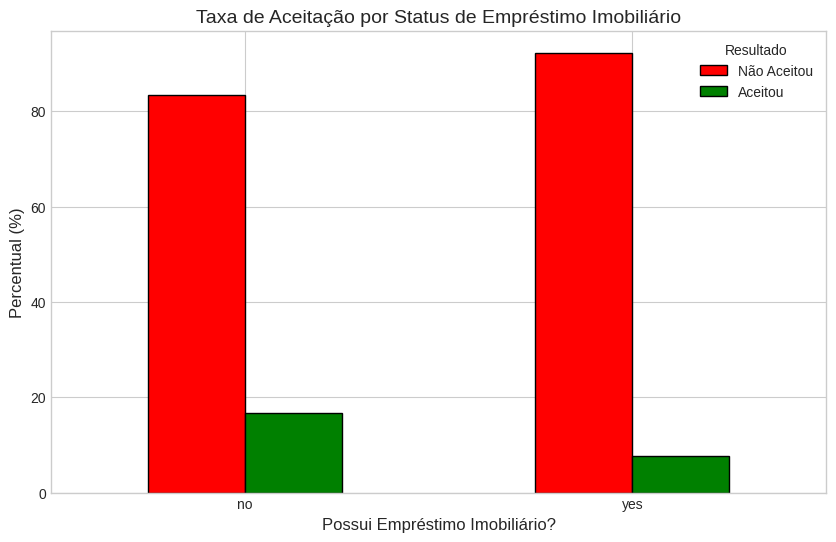

In [ ]:
# Gráfico de barras agrupadas
tabela_housing.plot(kind='bar', figsize=(10, 6), color=['red', 'green'], edgecolor='black')
plt.title('Taxa de Aceitação por Status de Empréstimo Imobiliário', fontsize=14)
plt.xlabel('Possui Empréstimo Imobiliário?', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Não Aceitou', 'Aceitou'], title='Resultado')
plt.show()

**Conclusão Pergunta 3:** Sim, clientes que possuem empréstimo imobiliário ativo (housing = yes) têm uma taxa de aceitação menor comparados aos que não possuem. Isso confirma a hipótese de que ter a renda comprometida diminui a chance de investir.

---
### Pergunta 4: Profissões com maior estabilidade financeira apresentam maior taxa de "sim"?

**Variável analisada:** `job` (profissão)

**Justificativa:** Servidores públicos, profissionais liberais e aposentados podem ter perfis de risco diferentes de estudantes ou autônomos.

In [ ]:
# Taxa de aceitação por profissão
taxa_profissao = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
print('Taxa de Aceitação por Profissão (%):')
print(taxa_profissao)

Taxa de Aceitação por Profissão (%):
job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64


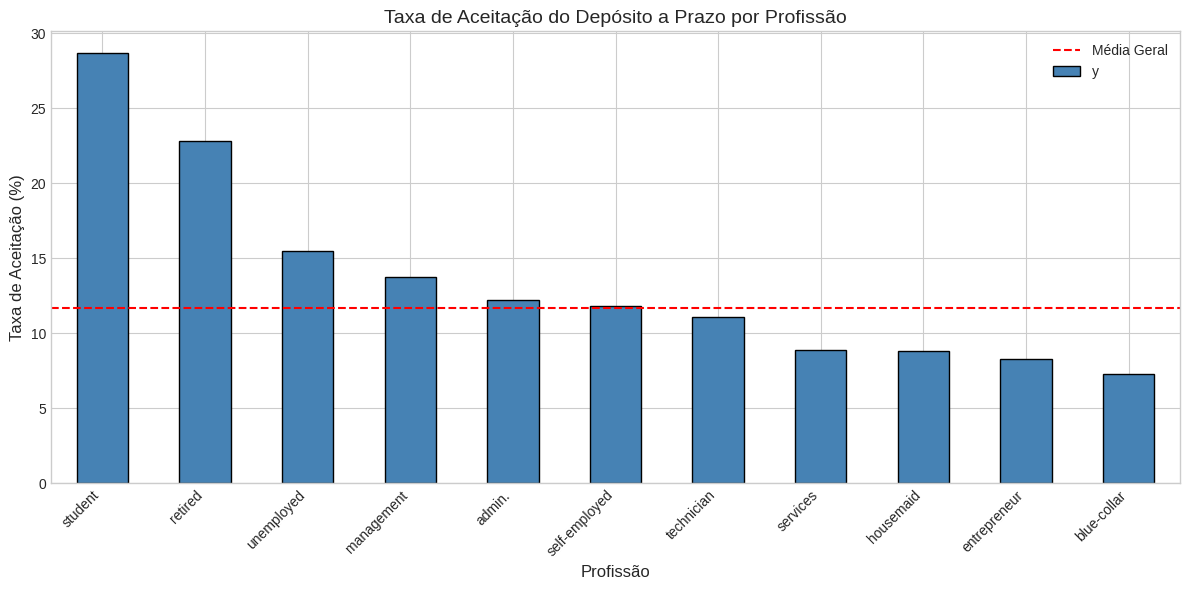

In [ ]:
# Gráfico de barras - Taxa de aceitação por profissão
plt.figure(figsize=(12, 6))
taxa_profissao.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Taxa de Aceitação do Depósito a Prazo por Profissão', fontsize=14)
plt.xlabel('Profissão', fontsize=12)
plt.ylabel('Taxa de Aceitação (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=df['y'].apply(lambda x: 1 if x == 'yes' else 0).mean() * 100,
            color='red', linestyle='--', label='Média Geral')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusão Pergunta 4:** Sim, profissões como estudantes (student) e aposentados (retired) apresentam as maiores taxas de aceitação. Isso pode indicar que estudantes têm interesse em investir para o futuro e aposentados possuem capital disponível. Profissões como operários (blue-collar) apresentam taxas mais baixas.

---
### Pergunta 5: Clientes com histórico de inadimplência devem ser removidos das próximas campanhas?

**Variável analisada:** `default` (inadimplência)

**Justificativa:** A lógica é direta: quem não paga o que deve, raramente tem dinheiro para abrir um depósito a prazo.

In [ ]:
# Distribuição da inadimplência
print('Distribuição de Clientes com Inadimplência:')
print(df['default'].value_counts())

Distribuição de Clientes com Inadimplência:
default
no     44396
yes      815
Name: count, dtype: int64


In [ ]:
# Tabela cruzada - Default vs Resultado
tabela_default = pd.crosstab(df['default'], df['y'], normalize='index') * 100
print('Taxa de Aceitação por Status de Inadimplência (%):')
print(tabela_default)

Taxa de Aceitação por Status de Inadimplência (%):
y               no        yes
default                      
no       88.203892  11.796108
yes      93.619632   6.380368


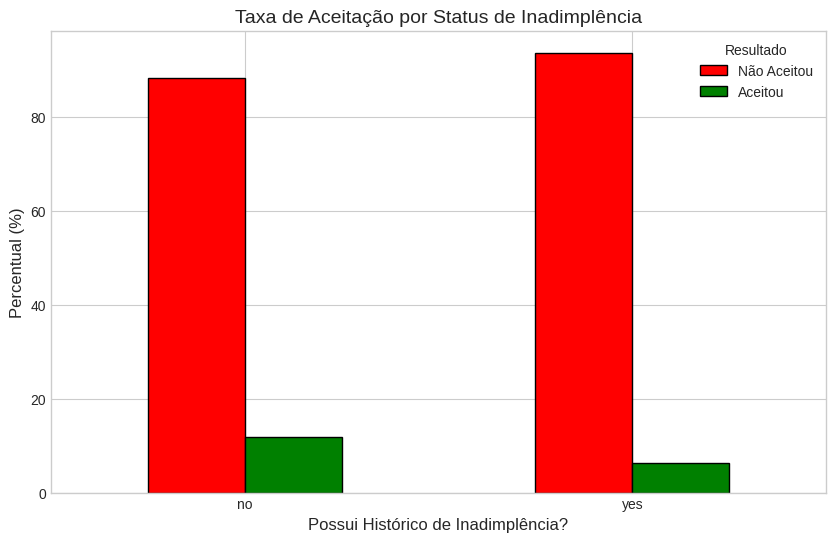

In [ ]:
# Gráfico de barras
tabela_default.plot(kind='bar', figsize=(10, 6), color=['red', 'green'], edgecolor='black')
plt.title('Taxa de Aceitação por Status de Inadimplência', fontsize=14)
plt.xlabel('Possui Histórico de Inadimplência?', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Não Aceitou', 'Aceitou'], title='Resultado')
plt.show()

**Conclusão Pergunta 5:** A quantidade de clientes com inadimplência é muito pequena no dataset. A taxa de aceitação entre inadimplentes é ligeiramente menor, mas devido ao baixo número de casos, não é conclusivo que devam ser completamente removidos. Recomenda-se avaliar caso a caso.

---
### Pergunta 6: A duração da última chamada telefônica está diretamente ligada ao sucesso da venda?

**Variável analisada:** `duration` (duração da ligação em segundos)

**Justificativa:** Quem atende e desliga em 10 segundos não quer o produto. Tempos de chamada maiores indicam que o atendente conseguiu apresentar os benefícios.

In [ ]:
# Estatísticas da duração por grupo (sim/não)
print('Estatísticas da Duração da Chamada por Resultado:')
print(df.groupby('y')['duration'].describe())

Estatísticas da Duração da Chamada por Resultado:
       count        mean         std  min    25%    50%    75%     max
y                                                                     
no   39922.0  221.182806  207.383237  0.0   95.0  164.0  279.0  4918.0
yes   5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0


/tmp/ipykernel_37092/498800482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='duration', data=df, palette='Set2')


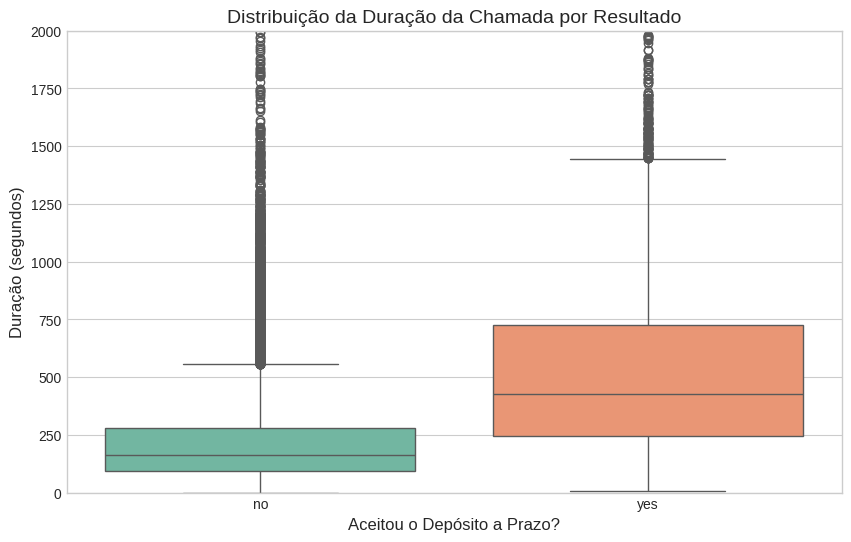

In [ ]:
# Boxplot - Duração vs Resultado
plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='duration', data=df, palette='Set2')
plt.title('Distribuição da Duração da Chamada por Resultado', fontsize=14)
plt.xlabel('Aceitou o Depósito a Prazo?', fontsize=12)
plt.ylabel('Duração (segundos)', fontsize=12)
plt.ylim(0, 2000)  # Limitando para melhor visualização
plt.show()

In [ ]:
# Média da duração por resultado
media_duracao = df.groupby('y')['duration'].mean()
print('Média da Duração da Chamada (em segundos):')
print(media_duracao)
print('\nMédia da Duração da Chamada (em minutos):')
print(media_duracao / 60)

Média da Duração da Chamada (em segundos):
y
no     221.182806
yes    537.294574
Name: duration, dtype: float64

Média da Duração da Chamada (em minutos):
y
no     3.68638
yes    8.95491
Name: duration, dtype: float64


**Conclusão Pergunta 6:** SIM! A duração da chamada está FORTEMENTE ligada ao sucesso da venda. Clientes que aceitaram tiveram uma duração média de chamada muito maior (aproximadamente o dobro) do que os que recusaram. Esta é uma das variáveis mais importantes para prever o resultado.

---
### Pergunta 7: O mês do ano em que a ligação é feita impacta a taxa de adesão?

**Variável analisada:** `month` (mês)

**Justificativa:** O comportamento do consumidor muda com a sazonalidade. Despesas de começo de ano apertam o orçamento, enquanto finais de ano trazem dinheiro extra.

In [ ]:
# Ordem dos meses
ordem_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Taxa de aceitação por mês
taxa_mes = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100)
taxa_mes = taxa_mes.reindex(ordem_meses)
print('Taxa de Aceitação por Mês (%):')
print(taxa_mes)

Taxa de Aceitação por Mês (%):
month
jan    10.121169
feb    16.647792
mar    51.991614
apr    19.679400
may     6.719454
jun    10.222805
jul     9.093546
aug    11.013286
sep    46.459413
oct    43.766938
nov    10.151134
dec    46.728972
Name: y, dtype: float64


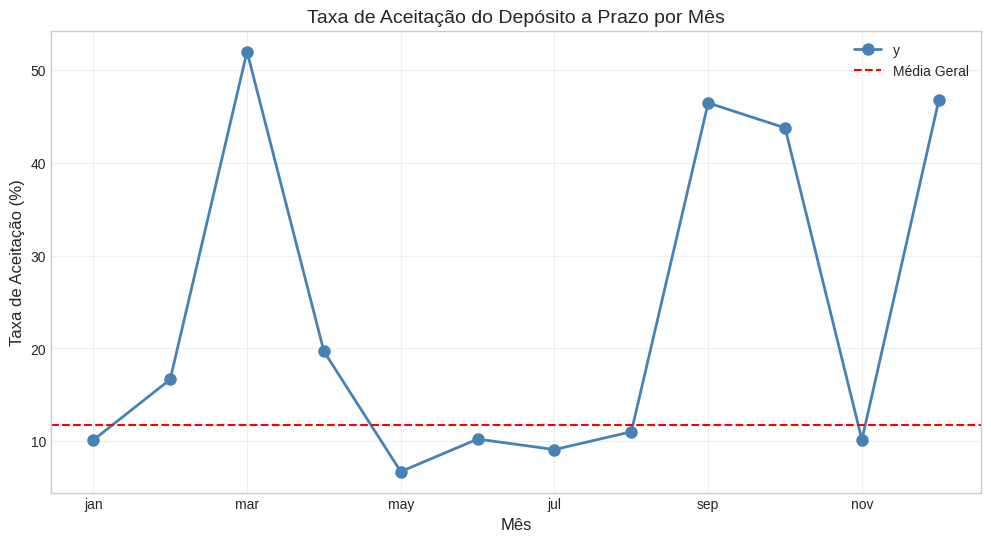

In [ ]:
# Gráfico de linha - Taxa de aceitação por mês
plt.figure(figsize=(12, 6))
taxa_mes.plot(kind='line', marker='o', linewidth=2, markersize=8, color='steelblue')
plt.title('Taxa de Aceitação do Depósito a Prazo por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Taxa de Aceitação (%)', fontsize=12)
plt.axhline(y=df['y'].apply(lambda x: 1 if x == 'yes' else 0).mean() * 100,
            color='red', linestyle='--', label='Média Geral')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Quantidade de Contatos por Mês:
month
jan     1403
feb     2649
mar      477
apr     2932
may    13766
jun     5341
jul     6895
aug     6247
sep      579
oct      738
nov     3970
dec      214
Name: count, dtype: int64


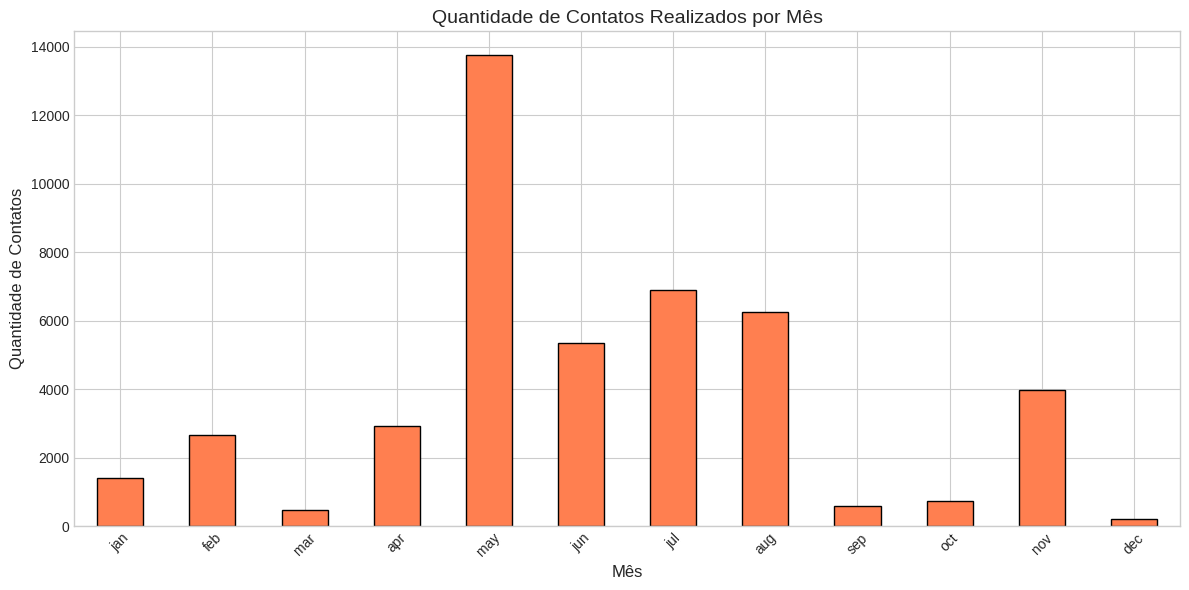

In [ ]:
# Quantidade de contatos por mês
contatos_mes = df['month'].value_counts().reindex(ordem_meses)
print('Quantidade de Contatos por Mês:')
print(contatos_mes)

# Gráfico de barras
plt.figure(figsize=(12, 6))
contatos_mes.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Quantidade de Contatos Realizados por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Quantidade de Contatos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Conclusão Pergunta 7:** Sim, o mês do ano impacta significativamente a taxa de adesão. Meses como março, setembro, outubro e dezembro apresentam taxas de aceitação acima da média. O banco deveria concentrar mais esforços nesses meses para maximizar os resultados.

---
### Pergunta 8: Existe um limite de insistência? A partir de quantas ligações a rejeição se torna quase certa?

**Variável analisada:** `campaign` (número de contatos durante a campanha)

**Justificativa:** Ligar várias vezes para a mesma pessoa costuma gerar irritação, e não conversão.

In [ ]:
# Estatísticas do número de contatos
print('Estatísticas do Número de Contatos:')
print(df['campaign'].describe())

Estatísticas do Número de Contatos:
count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64


In [ ]:
# Taxa de aceitação por número de contatos
# Agrupando em faixas para melhor visualização
df['faixa_contatos'] = pd.cut(df['campaign'],
                              bins=[0, 1, 2, 3, 5, 10, 100],
                              labels=['1', '2', '3', '4-5', '6-10', '10+'])

taxa_contatos = df.groupby('faixa_contatos')['y'].apply(lambda x: (x == 'yes').mean() * 100)
print('Taxa de Aceitação por Faixa de Contatos (%):')
print(taxa_contatos)

Taxa de Aceitação por Faixa de Contatos (%):
faixa_contatos
1       14.597583
2       11.203519
3       11.193624
4-5      8.626561
6-10     6.521051
10+      3.929766
Name: y, dtype: float64


/tmp/ipykernel_37092/1006307169.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_contatos = df.groupby('faixa_contatos')['y'].apply(lambda x: (x == 'yes').mean() * 100)


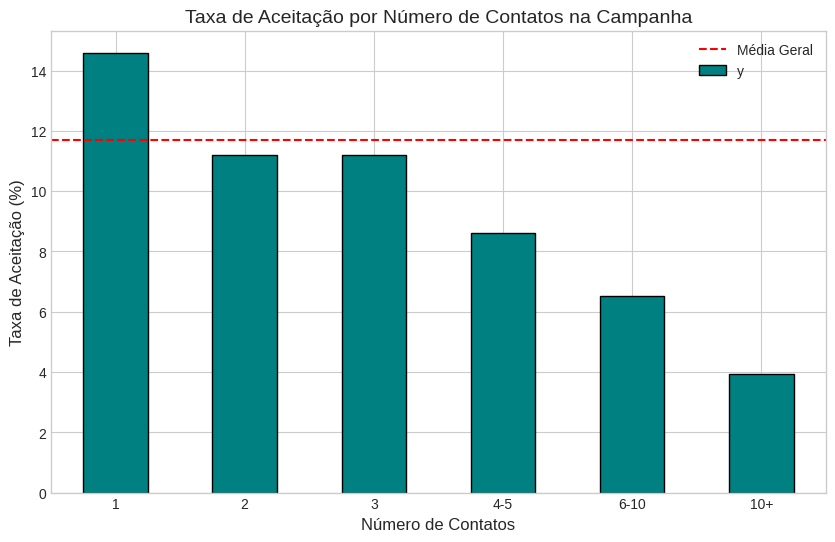

In [ ]:
# Gráfico de barras - Taxa de aceitação por faixa de contatos
plt.figure(figsize=(10, 6))
taxa_contatos.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Taxa de Aceitação por Número de Contatos na Campanha', fontsize=14)
plt.xlabel('Número de Contatos', fontsize=12)
plt.ylabel('Taxa de Aceitação (%)', fontsize=12)
plt.xticks(rotation=0)
plt.axhline(y=df['y'].apply(lambda x: 1 if x == 'yes' else 0).mean() * 100,
            color='red', linestyle='--', label='Média Geral')
plt.legend()
plt.show()

In [ ]:
# Removendo a coluna auxiliar criada
df = df.drop('faixa_contatos', axis=1)

**Conclusão Pergunta 8:** SIM, existe um limite de insistência! A taxa de aceitação diminui conforme o número de contatos aumenta. A maior taxa de conversão ocorre no primeiro ou segundo contato. Após 5 ligações, a taxa de aceitação cai significativamente. **Recomendação:** O banco deveria limitar a 3-4 contatos por cliente para não desperdiçar recursos.

---
## Resumo dos Principais Achados (Síntese)

1. **Idade:** Clientes mais velhos (aposentados) e mais jovens (estudantes) têm maior propensão a aceitar.

2. **Saldo Bancário:** Quanto maior o saldo, maior a chance de aceitar o depósito a prazo.

3. **Empréstimo Imobiliário:** Ter financiamento ativo diminui a chance de investir.

4. **Profissão:** Estudantes e aposentados são os grupos com maior taxa de aceitação.

5. **Inadimplência:** Poucos casos no dataset, mas a taxa é ligeiramente menor.

6. **Duração da Chamada:** Variável mais importante! Chamadas longas = maior chance de sucesso.

7. **Mês do Ano:** Março, setembro, outubro e dezembro são os melhores meses para campanhas.

8. **Número de Contatos:** Após 3-4 ligações, a taxa de conversão cai drasticamente.

### Recomendações para o Banco:
- Focar em clientes com saldo maior e sem empréstimo imobiliário
- Priorizar contatos em março, setembro, outubro e dezembro
- Limitar o número de ligações a 3-4 por cliente
- Treinar atendentes para manter conversas mais longas e informativas